In [10]:
import json
import os
import umap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.interpolate import CubicSpline
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import ipywidgets as widgets
from IPython.display import display

class ESBFeaturePlotter:
    """Visualize features with t-SNE, optionally highlighting one category."""

    def __init__(self, feature_dict):
        self.feature_dict = feature_dict

        self.names = list(feature_dict.keys())
        self.features = np.vstack([feature_dict[n]["feature"] for n in self.names])
        self.categories = [feature_dict[n]["category"] for n in self.names]
        self.unique_categories = sorted(set(self.categories))
        self.categories_np = np.array(self.categories)

        perplexity = min(30, max(2, len(self.names) - 1))
        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
        self.features_2d = tsne.fit_transform(self.features)

        # Fit once for NN queries
        self.nbrs = NearestNeighbors(n_neighbors=2, metric="cosine", algorithm="auto").fit(self.features)
        self.nn_indices = self.nbrs.kneighbors(self.features, return_distance=False)

    def nn_precision_for_category(self, highlight_category):
        """Precision@1 for queries from one category only."""
        mask = self.categories_np == highlight_category
        query_idx = np.where(mask)[0]

        if len(query_idx) == 0:
            return None

        correct = 0
        for i in query_idx:
            j = self.nn_indices[i, 1]  # nearest neighbor excluding self
            if self.categories_np[j] == highlight_category:
                correct += 1

        return correct / len(query_idx)

    def plot(self, highlight_category=None):
        fig, ax = plt.subplots(figsize=(10, 8))

        if highlight_category is None:
            ax.scatter(
                self.features_2d[:, 0],
                self.features_2d[:, 1],
                c="steelblue",
                s=12,
                alpha=0.75,
                label="All samples",
            )
            title = "t-SNE feature space"
        else:
            other_mask = np.array([c != highlight_category for c in self.categories])
            highlight_mask = ~other_mask

            ax.scatter(
                self.features_2d[other_mask, 0],
                self.features_2d[other_mask, 1],
                c="lightgrey",
                s=10,
                alpha=0.5,
                label="Other",
            )
            ax.scatter(
                self.features_2d[highlight_mask, 0],
                self.features_2d[highlight_mask, 1],
                c="red",
                s=20,
                alpha=0.9,
                label=highlight_category,
            )
            title = f"t-SNE feature space — '{highlight_category}' highlighted"

            # add class-only NN precision text
            p = self.nn_precision_for_category(highlight_category)
            txt = "NN precision: N/A" if p is None else f"NN precision ({highlight_category}): {p:.4f}"
            ax.text(
                0.02,
                0.98,
                txt,
                transform=ax.transAxes,
                va="top",
                ha="left",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
            )

        ax.legend()
        ax.set_title(title)
        ax.set_xlabel("t-SNE dim 1")
        ax.set_ylabel("t-SNE dim 2")
        plt.tight_layout()
        plt.show()


class UMAPTrainingAnimator:
    """
    Animate feature evolution across epochs using one fixed UMAP projection.

    Expected input format:
    {
        epoch: {
            object_name: {
                "category": "...",
                "feature": [...]
            },
            ...
        },
        ...
    }
    """

    def __init__(self, features_by_epoch, labels=None, random_state=42, **umap_kwargs):
        # Normalize epoch keys to int
        raw = {int(e): v for e, v in features_by_epoch.items()}
        self.epochs = sorted(raw.keys())
        if not self.epochs:
            raise ValueError("features_by_epoch is empty")

        # Find intersection of object names across all epochs
        all_epoch_dicts = list(raw.values())
        common_object_names = set(all_epoch_dicts[0].keys())
        for epoch_dict in all_epoch_dicts[1:]:
            common_object_names &= set(epoch_dict.keys())

        self.object_names = sorted(common_object_names)
        if not self.object_names:
            raise ValueError("No objects found in all epochs")

        # Build numeric feature matrices per epoch: {epoch: (N, D)}
        self.features_by_epoch = {}
        for e in self.epochs:
            epoch_dict = raw[e]
            rows = []
            for obj_name in self.object_names:
                item = epoch_dict[obj_name]
                feat = np.asarray(item["feature"], dtype=float).reshape(-1)
                rows.append(feat)

            x = np.vstack(rows)
            self.features_by_epoch[e] = x

        # Optional external labels (must be length N)
        self.labels = None if labels is None else np.asarray(labels)
        n_samples = len(self.object_names)
        if self.labels is not None and len(self.labels) != n_samples:
            raise ValueError("labels length must match number of objects/samples")

        self.reducer = umap.UMAP(
            n_components=2,
            random_state=random_state,
            **umap_kwargs
        )
        self.embeddings = {}
        self.fit_epoch = None

    def fit_and_transform(self, fit_epoch=None):
        if fit_epoch is None:
            fit_epoch = self.epochs[-1]
        if fit_epoch not in self.features_by_epoch:
            raise ValueError(f"fit_epoch {fit_epoch} not found in features_by_epoch")

        self.fit_epoch = fit_epoch
        self.reducer.fit(self.features_by_epoch[fit_epoch])

        for e in self.epochs:
            self.embeddings[e] = self.reducer.transform(self.features_by_epoch[e])

        return self.embeddings

    def _interpolated_embeddings(self, interp_factor=5):
        """
        Returns:
            t_dense: (T,) interpolated epoch positions
            emb_dense: (T, N, 2) interpolated embeddings
        """

        t = np.asarray(self.epochs, dtype=float)  # original epoch values, shape (E,)
        emb = np.stack([self.embeddings[e] for e in self.epochs], axis=0)  # (E, N, 2)

        if interp_factor <= 1 or len(t) < 2:
            return t, emb

        # Add intermediate frames between each epoch pair
        t_dense = np.linspace(t[0], t[-1], (len(t) - 1) * interp_factor + 1)

        # Cubic spline across epoch axis
        cs = CubicSpline(t, emb, axis=0)
        emb_dense = cs(t_dense)  # (T, N, 2)
        return t_dense, emb_dense

    def animate(
        self,
        save_path="training_umap.mp4",
        interval=300,
        fps=10,
        dpi=150,
        cmap="tab20",
        interp_factor=1,   # >1 for smoother animation
    ):
        if not self.embeddings:
            raise RuntimeError("Call fit_and_transform() before animate().")

        t_frames, emb_frames = self._interpolated_embeddings(interp_factor=interp_factor)

        all_emb = emb_frames.reshape(-1, 2)
        x_min, y_min = all_emb.min(axis=0) - 0.5
        x_max, y_max = all_emb.max(axis=0) + 0.5

        fig, ax = plt.subplots(figsize=(8, 6))
        scatter = ax.scatter(
            emb_frames[0, :, 0],
            emb_frames[0, :, 1],
            c=self.labels if self.labels is not None else "steelblue",
            s=12,
            cmap=cmap if self.labels is not None else None,
            alpha=0.8,
        )
        title = ax.set_title(f"Epoch {t_frames[0]:.2f} (UMAP fit on epoch {self.fit_epoch})")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel("UMAP dim 1")
        ax.set_ylabel("UMAP dim 2")

        def update(frame_idx):
            scatter.set_offsets(emb_frames[frame_idx])
            title.set_text(f"Epoch {t_frames[frame_idx]:.2f} (UMAP fit on epoch {self.fit_epoch})")
            return scatter, title

        ani = FuncAnimation(
            fig,
            update,
            frames=len(t_frames),
            interval=interval,
            blit=False,
            repeat=True,
        )

        print(f"Saving animation to {save_path}...")
        ani.save(save_path, writer="ffmpeg", fps=fps, dpi=dpi)
        print("Done!")
        plt.close(fig)
        return save_path


def get_feature_dict(feature_path, epochs):
    if isinstance(epochs, int):
        json_path = os.path.join(feature_path, f"ESB_features_{epochs}.json")
        with open(json_path, "rb") as f:
            feature_dict = json.load(f)
    elif isinstance(epochs, (list, tuple)):
        feature_dict = {}
        for e in epochs:
            json_path = os.path.join(feature_path, f"ESB_features_{e}.json")
            with open(json_path, "rb") as f:
                feature_dict[e] = json.load(f)
    else:
        raise ValueError("epochs must be int or list/tuple of ints")
        
    return feature_dict


def remove_top_principal_components(x, n_components=1, center=True):
    """
    Remove top principal component(s) from rows of x to reduce anisotropy.
    x: [N, D]
    """
    x = np.asarray(x, dtype=np.float32)
    if x.ndim != 2 or n_components <= 0:
        return x

    if center:
        x = x - x.mean(axis=0, keepdims=True)

    if x.shape[0] < 2:
        return x

    # SVD: right singular vectors are principal directions in feature space
    _, _, vh = np.linalg.svd(x, full_matrices=False)
    k = min(n_components, vh.shape[0])
    pcs = vh[:k]  # [k, D]

    # Remove projection onto top-k PCs
    x = x - (x @ pcs.T) @ pcs
    return x


def plot_class_cosine_similarity(feature_path, epoch, remove_top_pc=1):
    """
    Loads features via get_feature_dict and plots class-vs-class cosine similarity.
    Optionally removes top principal component(s) before cosine similarity.
    """
    feature_dict = get_feature_dict(feature_path, epochs=epoch)

    # Group features by class
    class_to_feats = {}
    for _, item in feature_dict.items():
        cls = item["category"]
        feat = np.asarray(item["feature"], dtype=np.float32).reshape(-1)
        class_to_feats.setdefault(cls, []).append(feat)

    classes = sorted(class_to_feats.keys())
    centroids = []
    for cls in classes:
        feats = np.vstack(class_to_feats[cls])  # [Nc, D]
        centroids.append(feats.mean(axis=0))    # [D]
    centroids = np.vstack(centroids)            # [C, D]

    # Remove dominant PC(s) to reduce anisotropy
    if remove_top_pc and remove_top_pc > 0:
        centroids = remove_top_principal_components(centroids, n_components=remove_top_pc, center=True)

    # Cosine similarity
    norms = np.linalg.norm(centroids, axis=1, keepdims=True) + 1e-12
    centroids_n = centroids / norms
    sim = centroids_n @ centroids_n.T

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(sim, cmap="viridis", vmin=-1.0, vmax=1.0)
    ax.set_title(f"Class cosine similarity (epoch {epoch}, removed_pc={remove_top_pc})")
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=90)
    ax.set_yticklabels(classes)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="cosine similarity")
    plt.tight_layout()
    plt.show()

    return classes, sim

def list_most_similar_classes(classes, sim, top_k=10, min_similarity=None):
    """
    List the most similar class pairs from a class-vs-class cosine similarity matrix.

    Args:
        classes: list[str], class names in the same order as sim.
        sim: np.ndarray shape [C, C], cosine similarity matrix.
        top_k: int, number of pairs to return.
        min_similarity: float or None, optional threshold to filter pairs.

    Returns:
        list of tuples: (class_a, class_b, similarity)
    """
    sim = np.asarray(sim, dtype=np.float32)
    c = len(classes)
    if sim.shape != (c, c):
        raise ValueError(f"sim shape {sim.shape} does not match number of classes {c}")

    pairs = []
    for i in range(c):
        for j in range(i + 1, c):  # upper triangle, excludes self-pairs
            s = float(sim[i, j])
            if (min_similarity is None) or (s >= min_similarity):
                pairs.append((classes[i], classes[j], s))

    pairs.sort(key=lambda x: x[2], reverse=True)
    top_pairs = pairs[:top_k]

    print(f"Top {len(top_pairs)} most similar class pairs:")
    for rank, (a, b, s) in enumerate(top_pairs, 1):
        print(f"{rank:2d}. {a}  <->  {b} : {s:.4f}")

    return top_pairs


In [11]:
FEATURES_PATH = "experiments/Transformer_ESB/ESB_models/test_finetune_ESB/features"

In [ ]:
plotter = ESBFeaturePlotter(get_feature_dict(FEATURES_PATH, epochs=0))

dropdown = widgets.Dropdown(
    options=["(None)"] + plotter.unique_categories,
    value="(None)",
    description="Highlight:",
)

out = widgets.Output()


def render(selected_value):
    selected = None if selected_value == "(None)" else selected_value
    with out:
        out.clear_output(wait=True)  # keeps only one plot visible
        plotter.plot(highlight_category=selected)


def on_change(change):
    if change["name"] == "value":
        render(change["new"])
        
dropdown.observe(on_change, names="value")
display(widgets.VBox([dropdown, out]))

# initial plot (single visible plot)
render(dropdown.value)

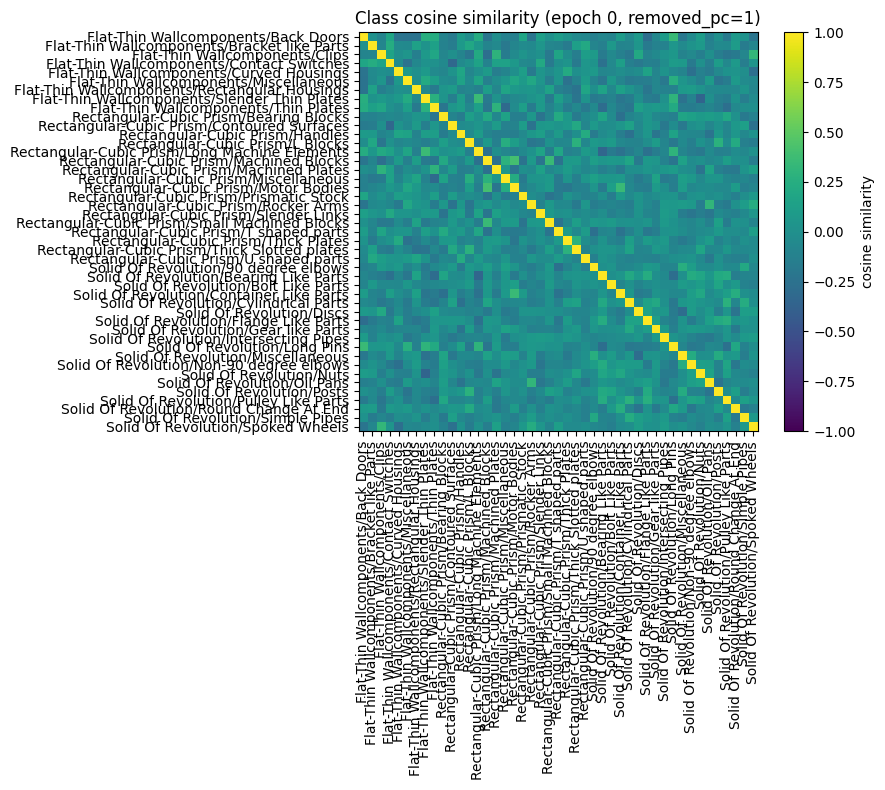

Top 10 most similar class pairs:
 1. Rectangular-Cubic Prism/Machined Blocks  <->  Rectangular-Cubic Prism/Motor Bodies : 0.4051
 2. Flat-Thin Wallcomponents/Slender Thin Plates  <->  Rectangular-Cubic Prism/Long Machine Elements : 0.3623
 3. Rectangular-Cubic Prism/Motor Bodies  <->  Solid Of Revolution/Container Like Parts : 0.3588
 4. Rectangular-Cubic Prism/Machined Blocks  <->  Rectangular-Cubic Prism/Small Machined Blocks : 0.3576
 5. Flat-Thin Wallcomponents/Back Doors  <->  Solid Of Revolution/Long Pins : 0.3547
 6. Flat-Thin Wallcomponents/Clips  <->  Solid Of Revolution/Spoked Wheels : 0.3263
 7. Rectangular-Cubic Prism/Rocker Arms  <->  Solid Of Revolution/Oil Pans : 0.3138
 8. Flat-Thin Wallcomponents/Slender Thin Plates  <->  Solid Of Revolution/Long Pins : 0.3032
 9. Rectangular-Cubic Prism/Long Machine Elements  <->  Solid Of Revolution/Long Pins : 0.3022
10. Flat-Thin Wallcomponents/Thin Plates  <->  Rectangular-Cubic Prism/Machined Plates : 0.2965


In [13]:
classes, sim = plot_class_cosine_similarity(FEATURES_PATH, epoch=0, remove_top_pc=1)
top_pairs = list_most_similar_classes(classes, sim, top_k=10)

In [ ]:
animator = UMAPTrainingAnimator(get_feature_dict(FEATURES_PATH, epochs=list(range(0,100,5))))
animator.fit_and_transform(fit_epoch=95)
animator.animate(save_path="training_umap.mp4", interval=80, fps=20, dpi=150, interp_factor=6)